In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from torch.utils.data import DataLoader
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.classes import torch_parse, TwoTowerModel
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle

In [2]:
# Get the MovieLens 100K dataset. You can input your own dataset here. 
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('../Dataset/ml-100k/u.data', sep='\t', names=columns)
print(df.head())

   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


In [3]:
# Define the number of epochs of the model training (`epochs`) and the threshold of early stopping to prevent overfitting (`patience`).
epochs = 100
patience = 3 # Stop training if validation loss doesn't improve for 3 consecutive epochs

### Preprocessing

In [4]:
# Remove rows with missing values in-place
df.dropna(inplace=True)

# Map user and item IDs to contiguous indices
user_to_idx = {uid: idx for idx, uid in enumerate(df['user_id'].unique())}
item_to_idx = {iid: idx for idx, iid in enumerate(df['item_id'].unique())}

idx_to_user = {idx: uid for uid, idx in user_to_idx.items()}
idx_to_item = {idx: iid for iid, idx in item_to_idx.items()}

num_users = len(user_to_idx)
num_items = len(item_to_idx)

df['user_idx'] = df['user_id'].map(user_to_idx)
df['item_idx'] = df['item_id'].map(item_to_idx)

# Training/validation/test sets (80-10-10 split)
train, temp = train_test_split(df, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

# Targets are the positive samples, which we define as ratings >= 3.
train_pos = train[train['rating'] >= 3].copy()
val_pos = val[val['rating'] >= 3].copy()
test_pos = test[test['rating'] >= 3].copy()

# Track all interactions of the training set for negative sampling 
user_rated_items = train.groupby('user_idx')['item_idx'].apply(set).to_dict()

### Training

In [5]:
# Create DataLoaders
train_dataset = torch_parse(train_pos, num_items, user_rated_items, num_negatives=4, is_training=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [6]:
@torch.no_grad()
def evaluate_retrieval(model, train_df, test_pos_df, num_users, num_items, K=10, batch_size=256):
    model.eval()
    device = next(model.parameters()).device
    
    # Pre-compute all item embeddings
    item_indices = torch.arange(num_items, dtype=torch.long).to(device)
    item_reps = []
    for i in range(0, num_items, batch_size):
        batch_items = item_indices[i:i+batch_size]
        item_reps.append(model.get_item_embeddings(batch_items))
    item_reps = torch.cat(item_reps, dim=0) # (num_items, 64)
    
    # Get ground truth positive items from test set
    test_user_pos_items = test_pos_df.groupby('user_idx')['item_idx'].apply(list).to_dict()
    # Mask out training set items so they aren't recommended
    train_user_items = train_df.groupby('user_idx')['item_idx'].apply(list).to_dict()
    
    test_users = list(test_user_pos_items.keys())
    if len(test_users) == 0:
        return 0.0, 0.0, 0.0
        
    precisions = []
    recalls = []
    ndcgs = []
    
    # Process test users in batches to avoid OOM
    # We can use a larger batch size compared to training because gradient computations are not needed.
    eval_batch_size = 1000
    for start_idx in range(0, len(test_users), eval_batch_size):
        batch_users = test_users[start_idx:start_idx + eval_batch_size]
        batch_users_tensor = torch.tensor(batch_users, dtype=torch.long).to(device)
        
        # Get embeddings for this batch of users
        user_reps_batch = model.get_user_embeddings(batch_users_tensor) # (eval_batch_size, 64)
        
        # Compute scores for this batch of users against all items
        # shape: (eval_batch_size, num_items)
        scores_batch = torch.matmul(user_reps_batch, item_reps.T).cpu().numpy()
        
        for i, user_idx in enumerate(batch_users):
            gt_items = test_user_pos_items[user_idx]
            if len(gt_items) == 0:
                continue
                
            user_scores = scores_batch[i]
            
            # Mask out training set items
            if user_idx in train_user_items:
                user_scores[train_user_items[user_idx]] = -np.inf
                
            top_k_indices = np.argsort(user_scores)[::-1][:K]
            hits = [1 if item in gt_items else 0 for item in top_k_indices]
            
            # Precision@K
            precision = sum(hits) / K
            precisions.append(precision)
            
            # Recall@K
            recall = sum(hits) / len(gt_items)
            recalls.append(recall)
            
            # NDCG@K
            idcg = sum([1 / np.log2(idx + 2) for idx in range(min(K, len(gt_items)))])
            dcg = sum([hit / np.log2(idx + 2) for idx, hit in enumerate(hits)])
            ndcg = dcg / idcg if idcg > 0 else 0
            ndcgs.append(ndcg)
            
    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = TwoTowerModel(num_users, num_items, embedding_dim=64).to(device)
criterion = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss is more numerically stable than Sigmoid (converts inputs to probabilities) followed by BCELoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

# Initial evaluation before training
p, r, n = evaluate_retrieval(model, train, test_pos, num_users, num_items, K=10)
print(f"Pre-train metrics - Precision@10: {p:.4f}, Recall@10: {r:.4f}, NDCG@10: {n:.4f}")

Using device: cpu
Pre-train metrics - Precision@10: 0.0053, Recall@10: 0.0046, NDCG@10: 0.0063


In [8]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
print(f"Starting training for {epochs} epochs...")

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        
        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * users.size(0)
    
    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)
    
    # Compute validation loss. No gradients needed.
    model.eval()
    val_total_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for users, items, labels in DataLoader(
            torch_parse(val_pos, num_items, user_rated_items, num_negatives=4, is_training=True),
            batch_size=256
        ):
            users, items, labels = users.to(device), items.to(device), labels.to(device)
            preds = model(users, items)
            v_loss = criterion(preds, labels)
            val_total_loss += v_loss.item() * users.size(0)
            val_count += users.size(0)
    avg_val_loss = val_total_loss / val_count
    val_losses.append(avg_val_loss)

    # Run retrieval evaluation on validation set
    val_p, val_r, val_n = evaluate_retrieval(model, train, val_pos, num_users, num_items, K=10)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Precision@10: {val_p:.4f}, Recall@10: {val_r:.4f}, NDCG@10: {val_n:.4f}")
    
    # Stop model training the moment model stops improving (ie. validation loss stops decreasing) for `patience` epochs in a row. (known as Early stopping)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pt')  # Save best weights
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}.")
        break

# Restore the best model before evaluation
model.load_state_dict(torch.load('best_model.pt'))

# Final Evaluation on test set
test_p, test_r, test_n = evaluate_retrieval(model, train, test_pos, num_users, num_items, K=10)
print(f"\nFinal Test Metrics - Precision@10: {test_p:.4f}, Recall@10: {test_r:.4f}, NDCG@10: {test_n:.4f}")

Starting training for 100 epochs...
Epoch 01/100 | Train Loss: 0.3858 | Val Loss: 0.3227 | Val Precision@10: 0.1201, Recall@10: 0.1624, NDCG@10: 0.1702
Epoch 02/100 | Train Loss: 0.3000 | Val Loss: 0.3049 | Val Precision@10: 0.1443, Recall@10: 0.2027, NDCG@10: 0.2104
Epoch 03/100 | Train Loss: 0.2750 | Val Loss: 0.2993 | Val Precision@10: 0.1457, Recall@10: 0.2048, NDCG@10: 0.2135
Epoch 04/100 | Train Loss: 0.2559 | Val Loss: 0.3004 | Val Precision@10: 0.1480, Recall@10: 0.2092, NDCG@10: 0.2160
Epoch 05/100 | Train Loss: 0.2375 | Val Loss: 0.3075 | Val Precision@10: 0.1512, Recall@10: 0.2179, NDCG@10: 0.2189
Epoch 06/100 | Train Loss: 0.2232 | Val Loss: 0.3101 | Val Precision@10: 0.1448, Recall@10: 0.2127, NDCG@10: 0.2158
Early stopping at epoch 6.

Final Test Metrics - Precision@10: 0.1494, Recall@10: 0.2102, NDCG@10: 0.2182


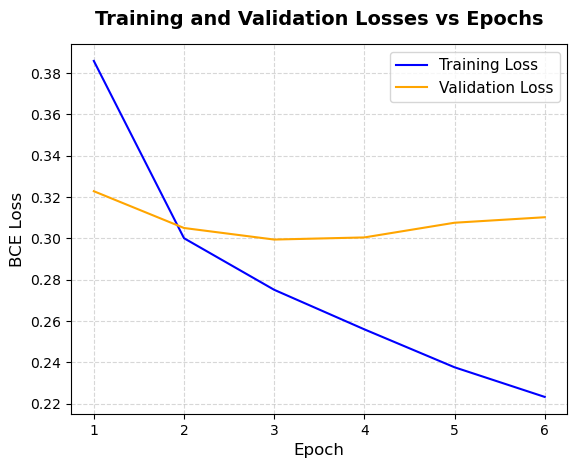

Plot saved to loss_curve.png


In [9]:
# Plot training and validation loss curves
epoch_range = range(1, epoch+2)

plt.plot(epoch_range, train_losses, color='blue', label='Training Loss')
plt.plot(epoch_range, val_losses, color='orange', label='Validation Loss')

# marker='o', linewidth=2, markersize=6,marker='s', linestyle='--'
plt.title('Training and Validation Losses vs Epochs', fontsize=14, fontweight='bold', pad=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.xticks(epoch_range)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

#plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to loss_curve.png')

### Inference

In [11]:
# Load Movie Titles
item_cols = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL', 
             'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime', 
             'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 
             'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
movies_df = pd.read_csv('../Dataset/ml-100k/u.item', sep='|', names=item_cols, encoding='latin-1')
movie_id_to_title = dict(zip(movies_df['movie_id'], movies_df['movie_title']))

# From the trained model, save item embeddings only.
with torch.no_grad():
    all_item_indices = torch.arange(num_items, dtype=torch.long)
    item_embeddings = model.get_item_embeddings(all_item_indices)  # (num_items, 64)

# Print number of users and movies in the dataset.
print(f"Dataset has {len(user_to_idx)} users, {len(item_to_idx)} movies.")

# Paths
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Save all artifacts
print("Saving artifacts...")
with open(f"{ARTIFACTS_DIR}/item_to_idx.pkl", "wb") as f:
    pickle.dump(item_to_idx, f)

with open(f"{ARTIFACTS_DIR}/idx_to_item.pkl", "wb") as f:
    pickle.dump(idx_to_item, f)

with open(f"{ARTIFACTS_DIR}/movie_id_to_title.pkl", "wb") as f:
    pickle.dump(movie_id_to_title, f)

torch.save(item_embeddings, f"{ARTIFACTS_DIR}/item_embeddings.pt")

print("All artifacts saved to ./artifacts/:")
for fname in os.listdir(ARTIFACTS_DIR):
    size = os.path.getsize(f"{ARTIFACTS_DIR}/{fname}")
    print(f"  {fname}  ({size:,} bytes)")
print("Done! You can now run: uvicorn api:app --reload")

Dataset has 943 users, 1682 movies.
Saving artifacts...
All artifacts saved to ./artifacts/:
  idx_to_item.pkl  (36,852 bytes)
  item_embeddings.pt  (432,225 bytes)
  item_to_idx.pkl  (36,852 bytes)
  movie_id_to_title.pkl  (48,970 bytes)
Done! You can now run: uvicorn api:app --reload


In [13]:
print("--- Movie Recommender Demo ---")

# Pick user_id = 1 for the demo
demo_user_id = 1
user_to_idx = {uid: idx for idx, uid in enumerate(df['user_id'].unique())}
demo_user_idx = user_to_idx[demo_user_id]

# Show user's top liked movies in the training set
liked_train = train[(train['user_idx'] == demo_user_idx) & (train['rating'] >= 4)]
liked_titles = [movie_id_to_title[idx_to_item[iid]] for iid in liked_train['item_idx']]
print(f"\nUser {demo_user_id}'s top rated movies in training set (showing first 5):")
for title in liked_titles[:5]:
    print(f"- {title}")

# Generate Top-10 Recommendations
model.eval()
with torch.no_grad():
    user_indices = torch.tensor([demo_user_idx], dtype=torch.long).to(device)
    user_rep = model.get_user_embeddings(user_indices)
    
    item_indices = torch.arange(num_items, dtype=torch.long).to(device)
    item_reps = model.get_item_embeddings(item_indices)
    
    # Calculate scores
    scores = torch.matmul(user_rep, item_reps.T).squeeze(0).cpu().numpy()
    
    # Mask out training set items
    train_user_items = train.groupby('user_idx')['item_idx'].apply(list).to_dict()
    rated_items_in_train = train_user_items.get(demo_user_idx, [])
    scores[rated_items_in_train] = -np.inf
    
    # Rank items
    top_recommendations = np.argsort(scores)[::-1][:10]

print(f"\nTop 10 movie recommendations for user {demo_user_id}:")
for idx, movie_idx in enumerate(top_recommendations):
    movie_id = idx_to_item[movie_idx]
    title = movie_id_to_title.get(movie_id, f"Unknown Movie (ID: {movie_id})")
    print(f"{idx+1}. {title} (Score: {scores[movie_idx]:.4f})")

--- Movie Recommender Demo ---

User 1's top rated movies in training set (showing first 5):
- Monty Python and the Holy Grail (1974)
- Willy Wonka and the Chocolate Factory (1971)
- When Harry Met Sally... (1989)
- Three Colors: White (1994)
- Dolores Claiborne (1994)

Top 10 movie recommendations for user 1:
1. Heathers (1989) (Score: 2.0842)
2. Raising Arizona (1987) (Score: 1.9914)
3. Back to the Future (1985) (Score: 1.8656)
4. Scream (1996) (Score: 1.7880)
5. Blues Brothers, The (1980) (Score: 1.6737)
6. Fargo (1996) (Score: 1.6249)
7. Return of the Jedi (1983) (Score: 1.6002)
8. Trainspotting (1996) (Score: 1.5173)
9. Get Shorty (1995) (Score: 1.4056)
10. English Patient, The (1996) (Score: 1.3841)
